# Preliminary Geometry-Based Assessment of Building-Induced Beam Blockage
## Tangerang C-Band Weather Radar (EEC DWSR-2501C)

**Tujuan:** Pemodelan awal berbasis geometri untuk menilai potensi beam blockage oleh bangunan tinggi terhadap radar cuaca C-Band Tangerang.

**Metode:**
1. Sudut halangan: α = arctan((H_b − H_r) / d)
2. Amplop beam: θ_lower = θ − β/2, θ_upper = θ + β/2
3. Klasifikasi: Clear / Partial / Severe

**Batasan:** Bukan DEM-based PBB, bukan validasi operasional.


In [15]:
# --- Imports & Setup ---
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

matplotlib.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.constrained_layout.use': True,
    'axes.grid': False,
})

OUT = Path('outputs')
FIGS = OUT / 'figures'
TABLES = OUT / 'tables'
for d in (FIGS, TABLES):
    d.mkdir(parents=True, exist_ok=True)

print("Setup complete.")


Setup complete.


In [16]:
# --- Raw Data (Source of Truth) ---
POINTS = {
    'P1_Radome_Center':       (-6.171432, 106.646610),
    'P2_Building_Near_Edge':  (-6.171528, 106.646219),
    'P3_Building_Center':     (-6.171638, 106.645763),
    'P4_Building_Far_Edge':   (-6.171761, 106.645262),
    'P5_Upper_Azimuth_Edge':  (-6.171434, 106.645934),
    'P6_Lower_Azimuth_Edge':  (-6.171718, 106.646104),
}

DISTANCES = {'D_min': 44.6, 'D_center': 96.5, 'D_max': 154.0}

AZIMUTHS = {
    'P1_P2': 256.216314572,
    'P1_P3': 256.341252108,
    'P1_P4': 256.295071523,
    'P1_P5': 269.830590206,
    'P1_P6': 240.544378890,
}

H_RADAR = 21.0
H_BUILDING = 39.0
H_DIFF = H_BUILDING - H_RADAR

BEAMWIDTH = 0.95
ELEVATIONS = [0.5, 1.5, 2.4, 3.4, 4.3, 6.0, 9.9, 14.6, 19.5]

print(f"H_diff = {H_DIFF} m | Beamwidth = {BEAMWIDTH} deg")
print(f"Distances: {DISTANCES}")


H_diff = 18.0 m | Beamwidth = 0.95 deg
Distances: {'D_min': 44.6, 'D_center': 96.5, 'D_max': 154.0}


In [17]:
# --- Core Functions ---
def obstruction_angle(h_building, h_radar, distance):
    return math.degrees(math.atan2(h_building - h_radar, distance))

def beam_envelope(elevation, beamwidth):
    half = beamwidth / 2.0
    return elevation - half, elevation + half

def classify_blockage(alpha, elevation, beamwidth):
    lower, upper = beam_envelope(elevation, beamwidth)
    if alpha < lower:
        return 'Clear'
    elif alpha <= upper:
        return 'Partial'
    else:
        return 'Severe'

print("Functions defined.")


Functions defined.


In [18]:
# --- Compute Obstruction Angles ---
obs_records = []
for name, dist in DISTANCES.items():
    alpha = obstruction_angle(H_BUILDING, H_RADAR, dist)
    obs_records.append({'Scenario': name, 'Distance_m': dist, 'Obstruction_Angle_deg': round(alpha, 2)})

obs_df = pd.DataFrame(obs_records)
display(obs_df)


,Scenario,Distance_m,Obstruction_Angle_deg
0,D_min,44.6,21.98
1,D_center,96.5,10.57
2,D_max,154.0,6.67


In [19]:
# --- Blockage Classification ---
class_records = []
for name, dist in DISTANCES.items():
    alpha = obstruction_angle(H_BUILDING, H_RADAR, dist)
    for elev in ELEVATIONS:
        cls = classify_blockage(alpha, elev, BEAMWIDTH)
        class_records.append({
            'Scenario': name, 'Distance_m': dist,
            'Elevation_deg': elev, 'Obstruction_Angle_deg': round(alpha, 2),
            'Classification': cls,
        })

class_df = pd.DataFrame(class_records)
class_matrix = class_df.pivot(index='Scenario', columns='Elevation_deg', values='Classification')
class_matrix = class_matrix.reindex(['D_min', 'D_center', 'D_max'])

class_df.to_csv(TABLES / 'blockage_classification.csv', index=False)
display(class_matrix)


Elevation_deg,0.5,1.5,2.4,3.4,4.3,6.0,9.9,14.6,19.5
Scenario,,,,,,,,,
D_min,Severe,Severe,Severe,Severe,Severe,Severe,Severe,Severe,Severe
D_center,Severe,Severe,Severe,Severe,Severe,Severe,Severe,Clear,Clear
D_max,Severe,Severe,Severe,Severe,Severe,Severe,Clear,Clear,Clear


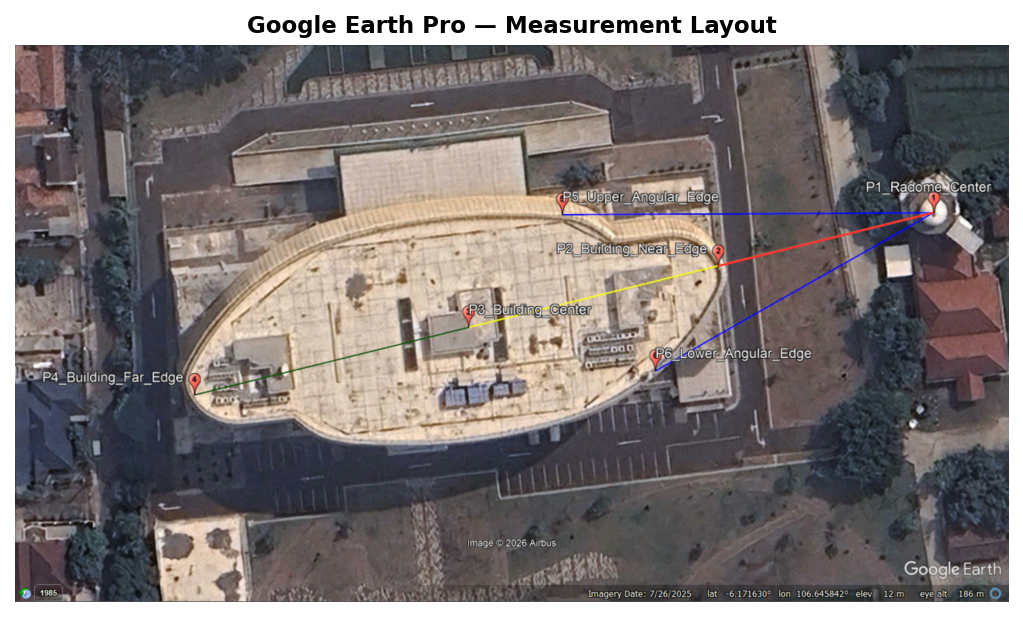

Fig. 1 saved.


In [20]:
# --- Fig. 1: Google Earth Measurement Layout ---
img_path = Path('data/Radar_Building_Distance_Measurement_Layout.png')

if img_path.exists():
    fig, ax = plt.subplots(figsize=(7.0, 4.0))
    img = mpimg.imread(str(img_path))
    ax.imshow(img)
    ax.set_title('Google Earth Pro \u2014 Measurement Layout')
    ax.axis('off')
    fig.savefig(FIGS / 'fig1_measurement_layout.png')
    plt.show()
    print("Fig. 1 saved.")
else:
    print(f"Image not found: {img_path}")


C:\Users\yasir\AppData\Local\Temp\ipykernel_28964\1407161224.py:51: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.88)


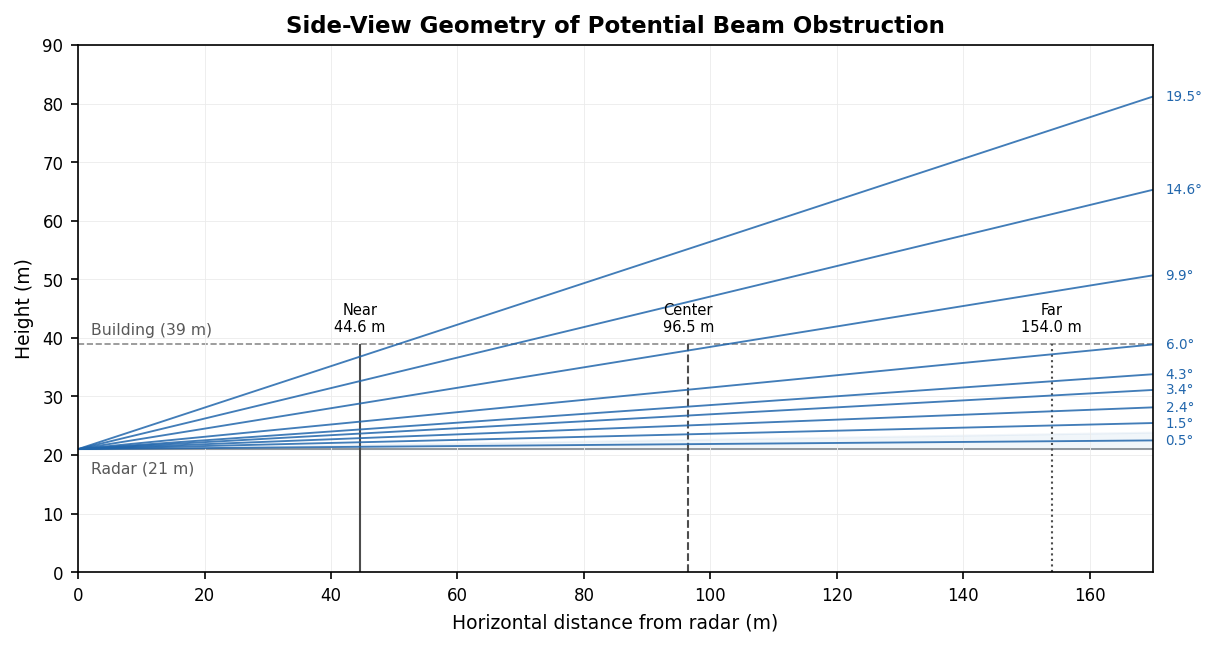

Fig. 2 saved.


In [21]:
# --- Fig. 2: Side-View Beam Obstruction Geometry ---
fig, ax = plt.subplots(figsize=(8.0, 4.2))

x_max = 170.0
x = np.linspace(0.1, x_max, 500)

# Height reference lines
ax.axhline(H_RADAR, color='0.55', lw=0.8, zorder=1)
ax.axhline(H_BUILDING, color='0.55', lw=0.8, ls='--', zorder=1)
ax.text(2, H_RADAR - 2.0, f'Radar ({H_RADAR:.0f} m)', fontsize=7.5, color='0.35', va='top')
ax.text(2, H_BUILDING + 1.0, f'Building ({H_BUILDING:.0f} m)', fontsize=7.5, color='0.35', va='bottom')

# Distance scenario vertical markers
scenario_info = [
    ('D_min', 44.6, 'Near\n44.6 m', '-'),
    ('D_center', 96.5, 'Center\n96.5 m', '--'),
    ('D_max', 154.0, 'Far\n154.0 m', ':'),
]
for _, dist, label, ls in scenario_info:
    ax.vlines(dist, 0, H_BUILDING, colors='0.3', linestyles=ls, lw=1.0)
    ax.text(dist, H_BUILDING + 1.5, label, fontsize=7, ha='center', va='bottom')

# ALL beam lines - uniform style
beam_color = '#2166ac'
beam_lw = 0.9
for elev in ELEVATIONS:
    y = H_RADAR + x * np.tan(np.radians(elev))
    ax.plot(x, y, color=beam_color, lw=beam_lw, alpha=0.85, zorder=2)

# Elevation labels - placed at end of each beam line, snapped to the line
label_x = x_max  # right at the edge of the plot area
for elev in ELEVATIONS:
    y_at_end = H_RADAR + label_x * np.tan(np.radians(elev))
    ax.text(label_x + 2, y_at_end, f'{elev}\u00b0', fontsize=6.5, color=beam_color,
            ha='left', va='center', clip_on=False)

# Beam envelope shading for 0.5 deg (lowest)
lo05, hi05 = beam_envelope(0.5, BEAMWIDTH)
y_lo = H_RADAR + x * np.tan(np.radians(lo05))
y_hi = H_RADAR + x * np.tan(np.radians(hi05))
ax.fill_between(x, y_lo, y_hi, color=beam_color, alpha=0.06, zorder=1)

ax.set_xlim(0, x_max)
ax.set_ylim(0, 90)
ax.set_xlabel('Horizontal distance from radar (m)')
ax.set_ylabel('Height (m)')
ax.set_title('Side-View Geometry of Potential Beam Obstruction')
ax.grid(True, color='0.92', lw=0.4)

# Extra right margin for labels
fig.subplots_adjust(right=0.88)

fig.savefig(FIGS / 'fig2_side_view_obstruction.png')
plt.show()
print("Fig. 2 saved.")


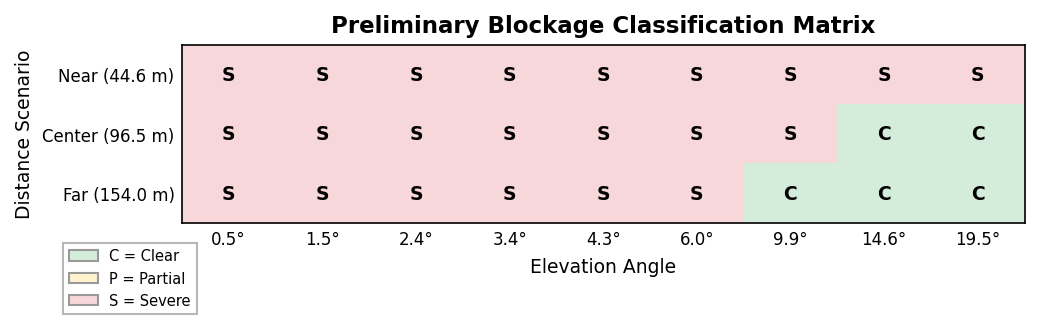

Fig. 3 saved.


In [22]:
fig, ax = plt.subplots(figsize=(7.0, 2.8), constrained_layout=False)

row_labels = ['Near (44.6 m)', 'Center (96.5 m)', 'Far (154.0 m)']
col_labels = ELEVATIONS

class_map = {'Clear': 0, 'Partial': 1, 'Severe': 2}
short_map = {0: 'C', 1: 'P', 2: 'S'}

heat = np.zeros((3, len(col_labels)), dtype=int)

for i, scen in enumerate(['D_min', 'D_center', 'D_max']):
    subset = class_df[class_df['Scenario'] == scen].set_index('Elevation_deg')
    heat[i, :] = [class_map[subset.loc[e, 'Classification']] for e in col_labels]

cmap = ListedColormap(['#d4edda', '#fff3cd', '#f8d7da'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

ax.imshow(heat, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(col_labels)))
ax.set_xticklabels([f'{e}\u00b0' for e in col_labels])
ax.set_yticks(range(3))
ax.set_yticklabels(row_labels)

ax.set_xlabel('Elevation Angle')
ax.set_ylabel('Distance Scenario')
ax.set_title('Preliminary Blockage Classification Matrix')

# cell annotation
for i in range(3):
    for j in range(len(col_labels)):
        ax.text(j, i, short_map[heat[i, j]],
                ha='center', va='center',
                fontsize=9, fontweight='bold')

legend_elements = [
    Patch(facecolor='#d4edda', edgecolor='0.6', label='C = Clear'),
    Patch(facecolor='#fff3cd', edgecolor='0.6', label='P = Partial'),
    Patch(facecolor='#f8d7da', edgecolor='0.6', label='S = Severe'),
]

ax.legend(
    handles=legend_elements,
    loc='lower left',
    bbox_to_anchor=(-0.15, -0.55),
    fontsize=7,
    framealpha=0.95,
    edgecolor='0.7',
    fancybox=False
)

ax.tick_params(length=0)

plt.tight_layout()

fig.savefig(FIGS / 'fig3_classification_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Fig. 3 saved.")

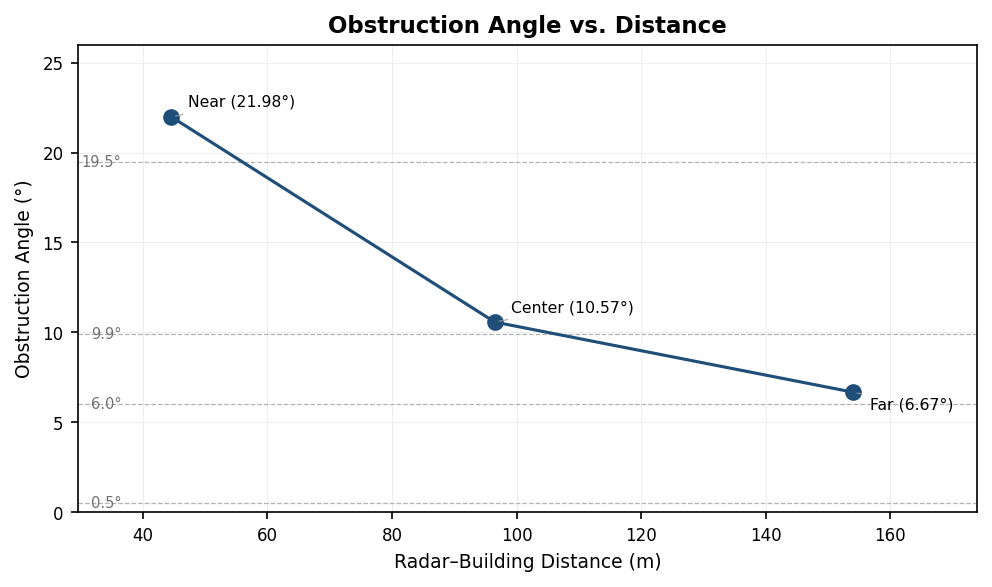

Fig. 4 saved.


In [23]:
# --- Fig. 4: Obstruction Angle vs Distance ---
fig, ax = plt.subplots(figsize=(6.5, 3.8))

dist_vals = obs_df['Distance_m'].values
angle_vals = obs_df['Obstruction_Angle_deg'].values
labels = ['Near', 'Center', 'Far']

ax.plot(dist_vals, angle_vals, 'o-', color='#1f4e79', lw=1.5, markersize=7, zorder=3)

# Point labels - carefully offset to avoid overlap
offsets_xy = [(8, 5), (8, 5), (8, -8)]
for d, a, lab, oxy in zip(dist_vals, angle_vals, labels, offsets_xy):
    ax.annotate(f'{lab} ({a:.2f}\u00b0)', (d, a),
                textcoords='offset points', xytext=oxy,
                ha='left', fontsize=7.5,
                arrowprops=dict(arrowstyle='-', color='0.6', lw=0.5))

# Reference elevation lines
ref_elevs = [0.5, 6.0, 9.9, 19.5]
for elev in ref_elevs:
    ax.axhline(elev, color='0.7', ls='--', lw=0.6)
    ax.text(min(dist_vals) - 8, elev, f'{elev}\u00b0', fontsize=7, color='0.45',
            va='center', ha='right')

ax.set_xlim(min(dist_vals) - 15, max(dist_vals) + 20)
ax.set_ylim(0, max(angle_vals) + 4)
ax.set_xlabel('Radar\u2013Building Distance (m)')
ax.set_ylabel('Obstruction Angle (\u00b0)')
ax.set_title('Obstruction Angle vs. Distance')
ax.grid(True, color='0.92', lw=0.4)

fig.savefig(FIGS / 'fig4_obstruction_angle_vs_distance.png')
plt.show()
print("Fig. 4 saved.")


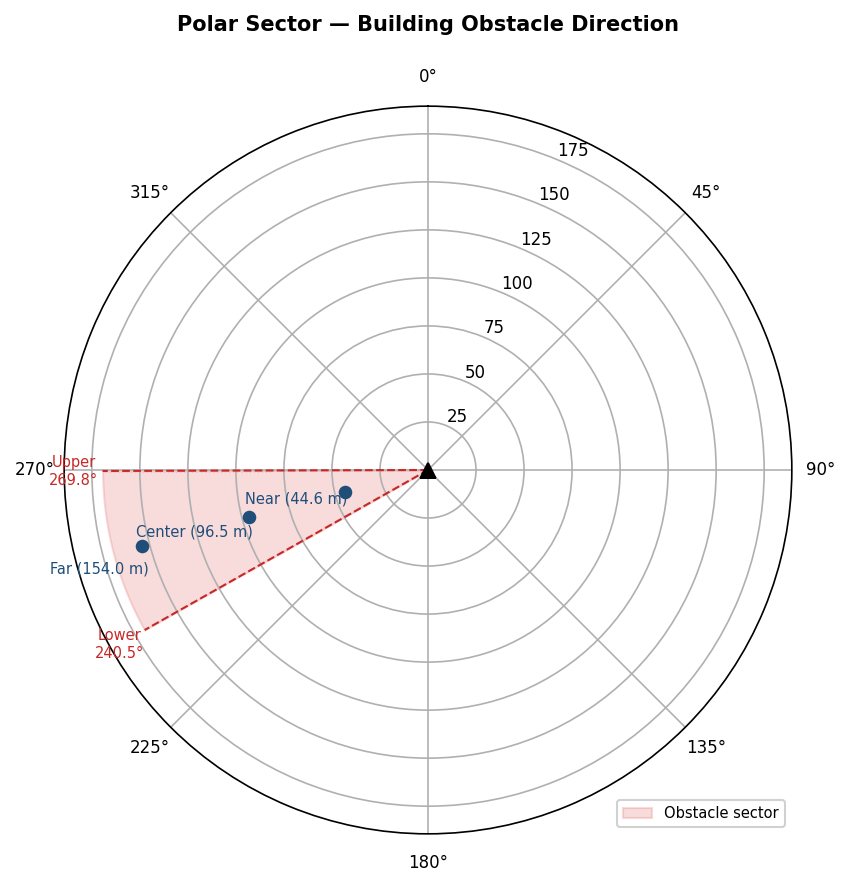

Fig. 5 saved.


In [24]:
# --- Fig. 5: Polar Sector of Building Obstacle ---
fig = plt.figure(figsize=(5.8, 5.8))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)

def az2theta(az_deg):
    return np.deg2rad(az_deg)

lower_az = AZIMUTHS['P1_P6']
upper_az = AZIMUTHS['P1_P5']
center_az = (lower_az + upper_az) / 2.0

# Obstacle sector - stronger fill for contrast
thetas_sector = np.linspace(az2theta(lower_az), az2theta(upper_az), 300)
r_max = DISTANCES['D_max'] * 1.1
ax.fill_between(thetas_sector, 0, r_max, color='#e57373', alpha=0.25, label='Obstacle sector')

# Sector boundary lines
for az, label in [(lower_az, f'Lower ({lower_az:.1f}\u00b0)'), (upper_az, f'Upper ({upper_az:.1f}\u00b0)')]:
    t = az2theta(az)
    ax.plot([t, t], [0, r_max], color='#c62828', lw=1.0, ls='--')

# Non-obstacle background is default (white) - clear contrast

# Distance markers along center azimuth
t_center = az2theta(center_az)
marker_info = [('Near', DISTANCES['D_min']), ('Center', DISTANCES['D_center']), ('Far', DISTANCES['D_max'])]
for label, dist in marker_info:
    ax.plot(t_center, dist, 'o', color='#1f4e79', markersize=5.5, zorder=3)
    # Offset text slightly to avoid overlap with marker
    ax.text(t_center - 0.08, dist, f'{label} ({dist} m)', fontsize=7,
            ha='right', va='center', color='#1f4e79')

# Boundary labels outside the plot
ax.text(az2theta(lower_az), r_max + 15, f'Lower\n{lower_az:.1f}\u00b0',
        fontsize=7, ha='center', va='center', color='#c62828')
ax.text(az2theta(upper_az), r_max + 15, f'Upper\n{upper_az:.1f}\u00b0',
        fontsize=7, ha='center', va='center', color='#c62828')

# Radar marker
ax.plot(0, 0, 'k^', markersize=7, zorder=4)

ax.set_ylim(0, r_max + 20)
ax.set_title('Polar Sector \u2014 Building Obstacle Direction', pad=18, fontsize=10)
ax.legend(loc='lower right', fontsize=7, framealpha=0.9)

fig.savefig(FIGS / 'fig5_polar_sector.png')
plt.show()
print("Fig. 5 saved.")


In [25]:
# --- Summary ---
print("=" * 50)
print("EXECUTION COMPLETE")
print("=" * 50)
print(f"\nCSV: {TABLES / 'blockage_classification.csv'}")
print(f"Figures: {FIGS}/fig1..fig5.png\n")

print("Obstruction angles:")
for _, r in obs_df.iterrows():
    print(f"  {r['Scenario']:>8s}: \u03b1 = {r['Obstruction_Angle_deg']:.2f}\u00b0")

print("\nClassification counts:")
for scen in ['D_min', 'D_center', 'D_max']:
    sub = class_df[class_df['Scenario'] == scen]
    s = (sub['Classification'] == 'Severe').sum()
    p = (sub['Classification'] == 'Partial').sum()
    c = (sub['Classification'] == 'Clear').sum()
    print(f"  {scen:>8s}: Severe={s}, Partial={p}, Clear={c}")


EXECUTION COMPLETE

CSV: outputs\tables\blockage_classification.csv
Figures: outputs\figures/fig1..fig5.png

Obstruction angles:
     D_min: α = 21.98°
  D_center: α = 10.57°
     D_max: α = 6.67°

Classification counts:
     D_min: Severe=9, Partial=0, Clear=0
  D_center: Severe=7, Partial=0, Clear=2
     D_max: Severe=6, Partial=0, Clear=3
